# Lomb-Scargle Testi (Tek Arc)

Belirli bir uydu, gözlem tipi ve arc numarası için `data/processed/PTLD00AUS_2022001_30S.parquet` dosyasından veri okunur.
`filter_dataset` ile elevation filtresi uygulanır (varsayılan: 2–15°).
SNR sinyali `detrend_snr` ile trendden arındırılır, ardından Lomb-Scargle spektral genlik spektrumu hesaplanır ve çizilir.
Maksimum genlik noktası işaretlenir; karşılık gelen reflektör yüksekliği gösterilir.

Ön koşul: `data/processed/PTLD00AUS_2022001_30S.parquet` dosyası mevcut olmalı (`python main.py` ile üretilir).

In [8]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.analysis.filters import filter_dataset
from src.analysis.lomb_scargle import calculate_lombscargle, detrend_snr

%matplotlib inline

In [9]:
# --- AYARLAR ---
PARQUET_PATH = os.path.join(
    PROJECT_ROOT, "data", "processed", "PTLD00AUS_2022001_30S.parquet"
)
TARGET_SAT = "G15"       # İncelenecek uydu (örn. G05, R10, C06)
TARGET_OBS_TYPE = "S2X"  # Arc'lar obsType bazında hesaplanır
TARGET_ARC_NO = 2        # İncelenecek arc numarası
POLY_DEGREE = 2          # detrend_snr polinom derecesi
ELEV_RANGES = [(2, 15)]  # filter_dataset elevation aralığı (derece)

# Lomb-Scargle arama parametreleri
H_MIN = 0.0
H_MAX = 10.0
PRECISION = 0.01

if not os.path.isfile(PARQUET_PATH):
    raise FileNotFoundError(
        f"Islenmis parquet dosyasi bulunamadi: {PARQUET_PATH}\nOnce `python main.py` calistirin."
    )

df = pd.read_parquet(PARQUET_PATH)

target_sat = TARGET_SAT.strip().upper()
target_obs_type = TARGET_OBS_TYPE.strip().upper()

sat_df = df[df["satID"].str.upper() == target_sat].copy()
available_obs_types = sorted(sat_df["obsType"].str.upper().unique().tolist())

arc_df = sat_df[
    (sat_df["obsType"].str.upper() == target_obs_type)
    & (sat_df["arcNo"] == TARGET_ARC_NO)
].copy()

if arc_df.empty:
    available_arcs = sorted(
        sat_df[sat_df["obsType"].str.upper() == target_obs_type]["arcNo"].unique().tolist()
    )
    raise ValueError(
        f"'{target_sat}' / '{target_obs_type}' / arcNo={TARGET_ARC_NO} icin veri yok.\n"
        f"Mevcut obsType'lar: {available_obs_types}\n"
        f"{target_sat} / {target_obs_type} icin mevcut arcNo'lar: {available_arcs}"
    )

n_before_filter = len(arc_df)

arc_df = filter_dataset(arc_df, elev_ranges=ELEV_RANGES)

if arc_df.empty:
    raise ValueError(
        f"'{target_sat}' / '{target_obs_type}' / arcNo={TARGET_ARC_NO} icin "
        f"elevation filtresi {ELEV_RANGES} sonrasi veri kalmadi.\n"
        f"Filtre oncesi satir sayisi: {n_before_filter}"
    )

arc_df = arc_df.sort_values("epoch").reset_index(drop=True)

elevations = arc_df["elevation"].to_numpy(dtype=float)
snr_values = arc_df["obsValue"].to_numpy(dtype=float)
wavelength_val = float(arc_df["wavelength"].iloc[0])
arc_type = int(arc_df["arcType"].iloc[0])

print(f"Dosya              : {PARQUET_PATH}")
print(f"Uydu / obsType     : {target_sat} / {target_obs_type}")
print(f"Arc No / Arc Type  : {TARGET_ARC_NO} / {arc_type}")
print(f"Elevation filtresi : {ELEV_RANGES}")
print(f"Veri noktasi sayisi: {len(arc_df)} (filtre oncesi: {n_before_filter})")
print(f"Epoch araligi      : {arc_df['epoch'].min()}  ->  {arc_df['epoch'].max()}")
print(f"Elevation araligi  : {elevations.min():.2f}°  ->  {elevations.max():.2f}°")
print(f"Wavelength (lambda): {wavelength_val:.4f} m")
print(f"Polinom derecesi   : {POLY_DEGREE}")
arc_df.head()

Dosya              : c:\vscode_workspace\PyReflection\data\processed\PTLD00AUS_2022001_30S.parquet
Uydu / obsType     : G15 / S2X
Arc No / Arc Type  : 2 / -1
Elevation filtresi : [(2, 15)]
Veri noktasi sayisi: 72 (filtre oncesi: 277)
Epoch araligi      : 2022-01-01 05:47:30  ->  2022-01-01 06:24:30
Elevation araligi  : 2.02°  ->  14.91°
Wavelength (lambda): 0.2442 m
Polinom derecesi   : 2


,epoch,constellation,satID,arcNo,arcType,obsType,wavelength,obsValue,elevation,azimuth
0,2022-01-01 05:47:30,G,G15,2,-1,S2X,0.24421,61.659500,14.912785,137.260549
1,2022-01-01 05:48:00,G,G15,2,-1,S2X,0.24421,64.565423,14.743905,137.331461
2,2022-01-01 05:48:30,G,G15,2,-1,S2X,0.24421,63.826349,14.574796,137.401415
3,2022-01-01 05:49:00,G,G15,2,-1,S2X,0.24421,69.984200,14.405462,137.470414
4,2022-01-01 05:49:30,G,G15,2,-1,S2X,0.24421,70.794578,14.235906,137.538462


In [10]:
# Trendden arindirma ve Lomb-Scargle hesabi
detrended_snr = detrend_snr(elevations, snr_values, poly_degree=POLY_DEGREE)

h_grid, spectral_amplitude = calculate_lombscargle(
    elevation=elevations,
    detrended_snr=detrended_snr,
    wavelength=wavelength_val,
    h_min=H_MIN,
    h_max=H_MAX,
    precision=PRECISION,
)

peak_idx = int(np.argmax(spectral_amplitude))
peak_h = float(h_grid[peak_idx])
peak_amp = float(spectral_amplitude[peak_idx])
mean_amp = float(np.mean(spectral_amplitude))
pbnr = peak_amp / mean_amp

print(f"Baskin reflektor yuksekligi: {peak_h:.2f} m")
print(f"Maksimum spektral genlik     : {peak_amp:.4f}")
print(f"PBNR (tepe / ortalama genlik): {pbnr:.2f}")

Baskin reflektor yuksekligi: 4.65 m
Maksimum spektral genlik     : 11.4815
PBNR (tepe / ortalama genlik): 6.08


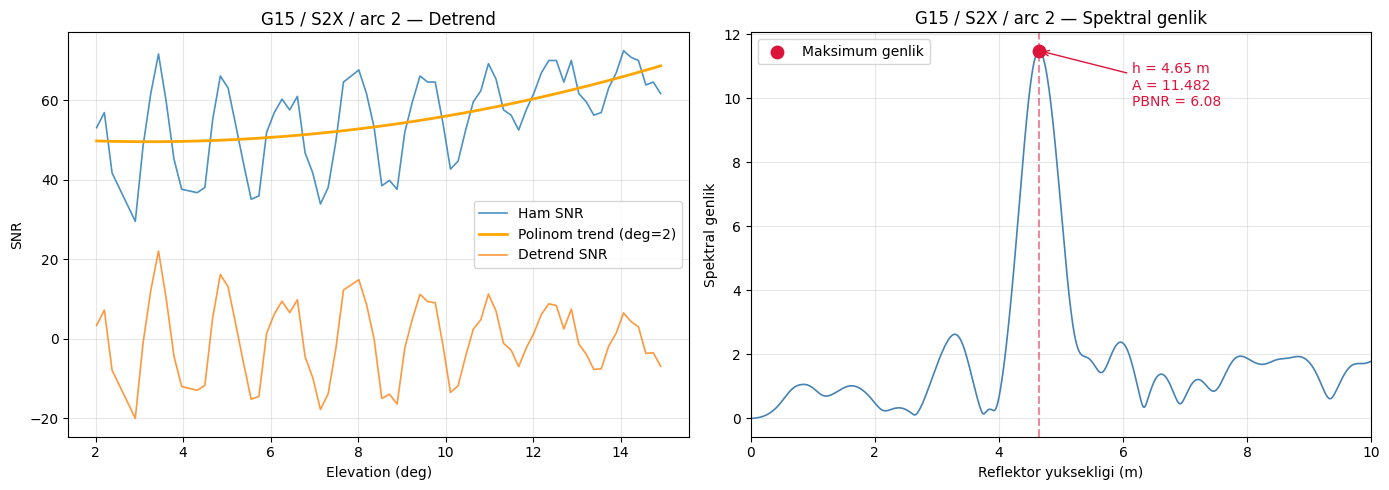

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: ham SNR ve detrend edilmis SNR
ax0 = axes[0]
trend = snr_values - detrended_snr
ax0.plot(elevations, snr_values, linewidth=1.2, alpha=0.8, label="Ham SNR")
ax0.plot(elevations, trend, color="orange", linewidth=2, label=f"Polinom trend (deg={POLY_DEGREE})")
ax0.plot(elevations, detrended_snr, linewidth=1.2, alpha=0.8, label="Detrend SNR")
ax0.set_xlabel("Elevation (deg)")
ax0.set_ylabel("SNR")
ax0.set_title(f"{target_sat} / {target_obs_type} / arc {TARGET_ARC_NO} — Detrend")
ax0.legend()
ax0.grid(True, alpha=0.3)

# Sag: Lomb-Scargle spektral genlik spektrumu
ax1 = axes[1]
ax1.plot(h_grid, spectral_amplitude, color="steelblue", linewidth=1.2)
ax1.scatter([peak_h], [peak_amp], color="crimson", s=80, zorder=5, label="Maksimum genlik")
ax1.axvline(peak_h, color="crimson", linestyle="--", alpha=0.5)
ax1.annotate(
    f"h = {peak_h:.2f} m\nA = {peak_amp:.3f}\nPBNR = {pbnr:.2f}",
    xy=(peak_h, peak_amp),
    xytext=(peak_h + 1.5, peak_amp * 0.85),
    arrowprops=dict(arrowstyle="->", color="crimson"),
    fontsize=10,
    color="crimson",
)
ax1.set_xlabel("Reflektor yuksekligi (m)")
ax1.set_ylabel("Spektral genlik")
ax1.set_title(f"{target_sat} / {target_obs_type} / arc {TARGET_ARC_NO} — Spektral genlik")
ax1.set_xlim(H_MIN, H_MAX)
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()